# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Afsheen Afifa



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np


# Data Visualisation
import matplotlib.pyplot as plt


# Machine Learning Utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV


# Data Preprocessing
from sklearn.preprocessing import LabelEncoder


# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier)


# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Model Saving
import joblib



# 1. Business Understanding

## Project Background

Student academic performance is an important indicator of educational success and plays a key role in helping schools provide appropriate academic support. However, educators often face challenges in identifying students who are at risk of poor academic performance before final examination results are released. Without early identification, these students may miss opportunities for timely intervention, personalised guidance, and additional learning support.

## Project Goal

The objective of this project is to develop a **machine learning classification model** that predicts a student's final grade category (**A, B, C, or D**) using demographic, family, social, and academic information from the Student Performance dataset. By predicting students' likely academic outcomes before final grades are available, the model can assist educators in identifying students who may require additional support and enable data-driven educational decision-making.

## Business Impact

An accurate prediction model can support teachers and school administrators in monitoring student performance, identifying at-risk students, and allocating educational resources more effectively. Early identification enables schools to provide targeted interventions and personalised support, which may improve students' academic performance and overall educational outcomes. 

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
FILE_PATH= "student grade prediction.xlsx"
df = pd.read_excel(FILE_PATH, sheet_name="student-por") ## Read the data from the excel file
df ## Display dataframe



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10



The dataset was successfully loaded into a pandas DataFrame. Displaying the rows provides an initial overview of the dataset, allowing the features, data values, and overall structure to be verified before performing data exploration and preprocessing. This step ensures that the correct worksheet has been imported and that the dataset is ready for further analysis.


## 2.2 Summary Statistics

Before preprocessing the dataset, it is important to examine its overall structure and quality to ensure the data is suitable for machine learning. This section analyses the dataset's dimensions, data types, missing values, and summary statistics to identify potential issues such as incomplete data, incorrect data types, or unusual values that may affect model performance. Understanding these characteristics provides a solid foundation for data preprocessing and helps guide subsequent feature engineering and model development.

In [3]:
# Display the dimensions of the dataset (rows and columns)
print("Dataset Shape:", df.shape)

# Display the dataset structure, data types, and non-null values
print("\nDataset Information:")
df.info()

# Check for missing values in each column
print("\nMissing Values:")
display(df.isnull().sum())

# Display summary statistics for numerical features
print("\nNumerical Features:")
display(df.describe())

# Display summary statistics for categorical features
print("\nCategorical Features:")
display(df.describe(include="object"))

Dataset Shape: (649, 33)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nur

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


Numerical Features:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000



Categorical Features:


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,423,383,452,457,569,258,367,285,455,581,398,610,334,521,580,498,410


### Interpretation

The Student Performance dataset contains **649 student records** and **33 features**, representing demographic, family, social, lifestyle, and academic factors collected from Portuguese secondary school students. These features will be used to predict students' final academic grade categories (A, B, C, and D). 

The info() output shows that the dataset consists of both numerical and categorical variables, which indicates that preprocessing techniques such as encoding categorical features will be required before training the machine learning models.

The missing value analysis confirms that all features contain complete data with **no missing values**. As a result, data imputation is not required, allowing the modelling process to proceed without additional handling for incomplete records.

The summary statistics provide an overview of the numerical and categorical features. Variables such as **study time, previous failures, absences, parental education, and academic grades (G1, G2, and G3)** are particularly relevant because they may influence students' academic performance. Understanding these feature distributions helps identify suitable preprocessing steps and supports later feature engineering and model development.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target(G3)

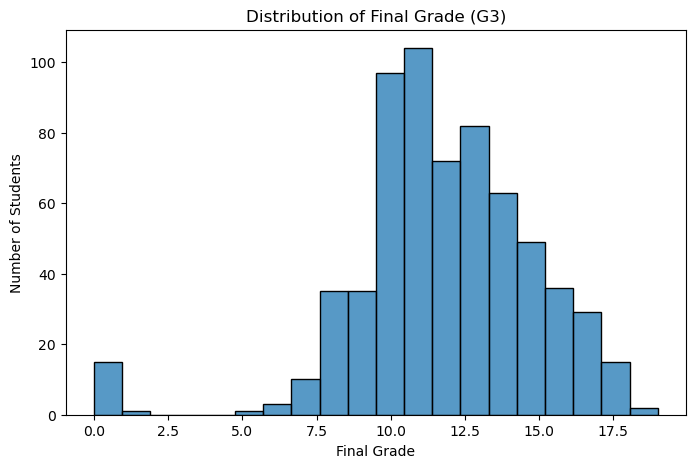

In [4]:
# Import the Seaborn library for statistical visualisation
import seaborn as sns

# Create a histogram to visualise the distribution of students' final grades (G3)
plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=20)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

# Display the histogram
plt.show()

### Interpretation

The histogram shows the distribution of students' final grades and most students achieved **mid-range grades** around 10.0 to 11.0, while relatively few students obtained either very low or very high scores. This indicates that student performance is concentrated around the middle grade range rather than being evenly distributed across all possible grades.

From a business perspective, this suggests that the majority of students perform at an average academic level, while only a small proportion are either high-performing or academically at risk. Identifying these lower-performing students is particularly important because they may benefit from early academic intervention and additional educational support.

From a modelling perspective, understanding the target variable's distribution is essential before converting the numerical **G3** scores into grade categories (A, B, C, and D). If some grade categories contain significantly fewer students than others, class imbalance may affect model performance and should be considered during model evaluation.

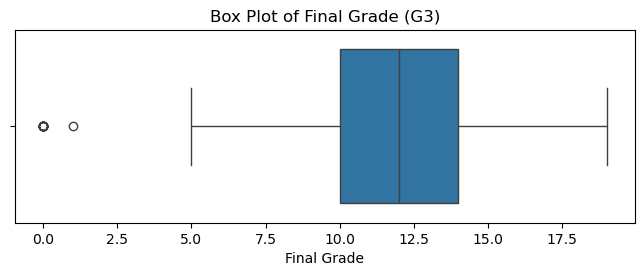

In [5]:
# Create a box plot to identify the spread and potential outliers in students' final grades
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df["G3"])

plt.title("Box Plot of Final Grade (G3)")
plt.xlabel("Final Grade")

plt.show()

The box plot also shows majority have marks that range from 10.0 to 14.0 and only a few students get very high or low marks.

## 2.3.1.2 Distribution of Features

After examining the target variable, it is important to understand the distribution of the input features. Visualising the feature distributions helps identify patterns, potential outliers, and data imbalances that may influence model performance. These insights also support feature engineering and provide a better understanding of the factors that may affect students' academic performance.

## Study Time

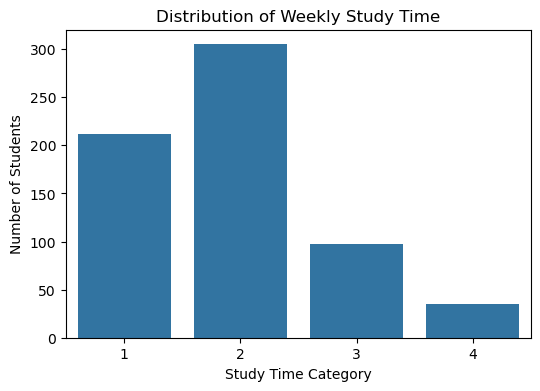

In [6]:

# Display the distribution of weekly study time

plt.figure(figsize=(6,4))
sns.countplot(x="studytime", data=df)

plt.title("Distribution of Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()


The count plot shows that most students reported **moderate weekly study time**, while relatively few students studied for the highest number of hours. This suggests that the majority of students dedicate a similar amount of time to studying, with fewer students investing significantly more time.

From a business perspective, study time is an important academic behaviour that may influence student performance. From a modelling perspective, understanding its distribution helps determine whether study habits are balanced across the dataset and whether the feature is suitable for predicting students' final grade categories.

# Absences

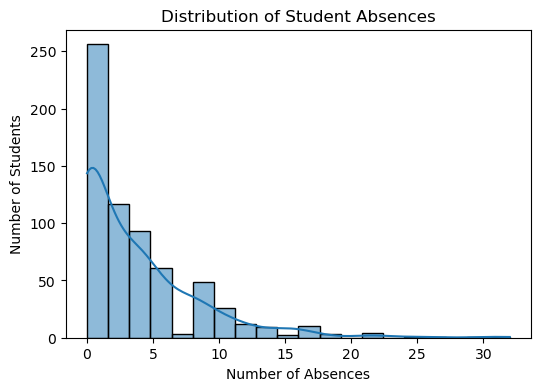

In [7]:
# Visualise the distribution of student absences
plt.figure(figsize=(6, 4))
sns.histplot(df["absences"], bins=20, kde=True)

# Add chart title and axis labels
plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")

# Display the chart
plt.show()


The histogram indicates that most students recorded relatively **few absences**, while a smaller number accumulated a much higher number of absences. This creates a right-skewed distribution, the extreme values may represent outliers and could influence model performance.

From a business perspective, attendance is an important indicator of student engagement and may influence academic achievement. From a modelling perspective, the distribution suggests that absences may be a useful predictor of final academic performance.

# Failures

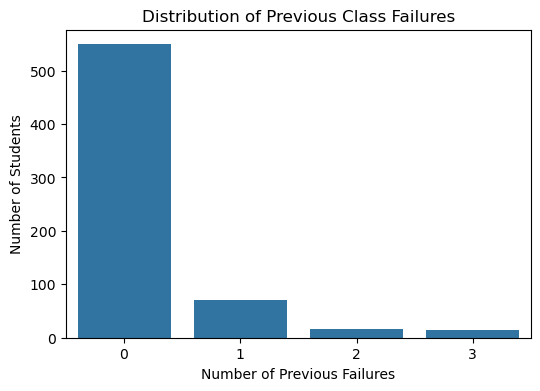

In [8]:
# Display the distribution of previous class failures

plt.figure(figsize=(6,4))
sns.countplot(x="failures", data=df)

plt.title("Distribution of Previous Class Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()


The majority of students recorded **no previous class failures**, while progressively fewer students had one or more failures. This indicates that most students in the dataset have maintained satisfactory academic progress.

From a business perspective, previous failures may indicate students who require additional academic support. From a modelling perspective, this feature is likely to be informative because past academic performance often influences future educational outcomes.

# Going out with friends

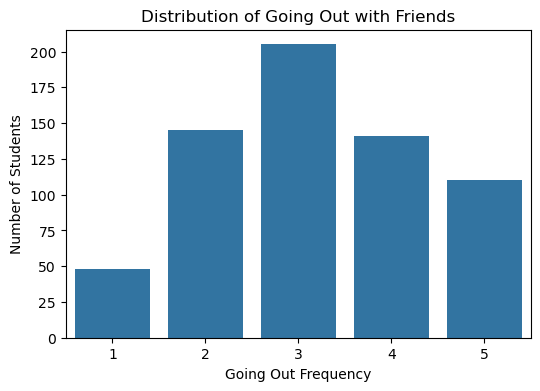

In [9]:
# Visualise how frequently students go out with friends
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="goout")

# Add chart title and axis labels
plt.title("Distribution of Going Out with Friends")
plt.xlabel("Going Out Frequency")
plt.ylabel("Number of Students")

# Display the chart
plt.show()


The distribution shows that most students reported **moderate levels of social activity**, while relatively few students selected the lowest or highest frequency. This suggests that students generally maintain balanced social lifestyles.

From a business perspective, social activities may influence study habits and academic performance. From a modelling perspective, analysing this feature helps determine whether lifestyle factors contribute to predicting students' final grade categories.

# Desire for Higher Education

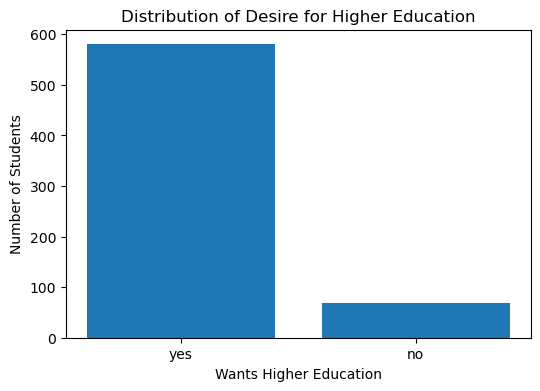

In [10]:
# Distribution of Desire for Higher Education

higher_counts = df["higher"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(higher_counts.index, higher_counts.values)

plt.title("Distribution of Desire for Higher Education")
plt.xlabel("Wants Higher Education")
plt.ylabel("Number of Students")

plt.show()


The majority of students indicated that they **intend to pursue higher education**, while only a very small proportion responded otherwise. This suggests that most students have aspirations to continue their education beyond secondary school.

From a business perspective, students with higher educational aspirations may demonstrate greater academic motivation. From a modelling perspective, this feature may contribute to predicting final grade categories by capturing differences in students' educational goals.

### 2.3.2 Understanding Relationship Between Variables

After examining the distribution of individual features, the next step is to analyse the relationships between variables. Understanding these relationships helps identify which features are most strongly associated with students' final academic performance and provides valuable insights for feature selection and model development. This section uses correlation analysis and feature-target visualisations to identify variables that are likely to have the greatest influence on predicting students' final grade categories.

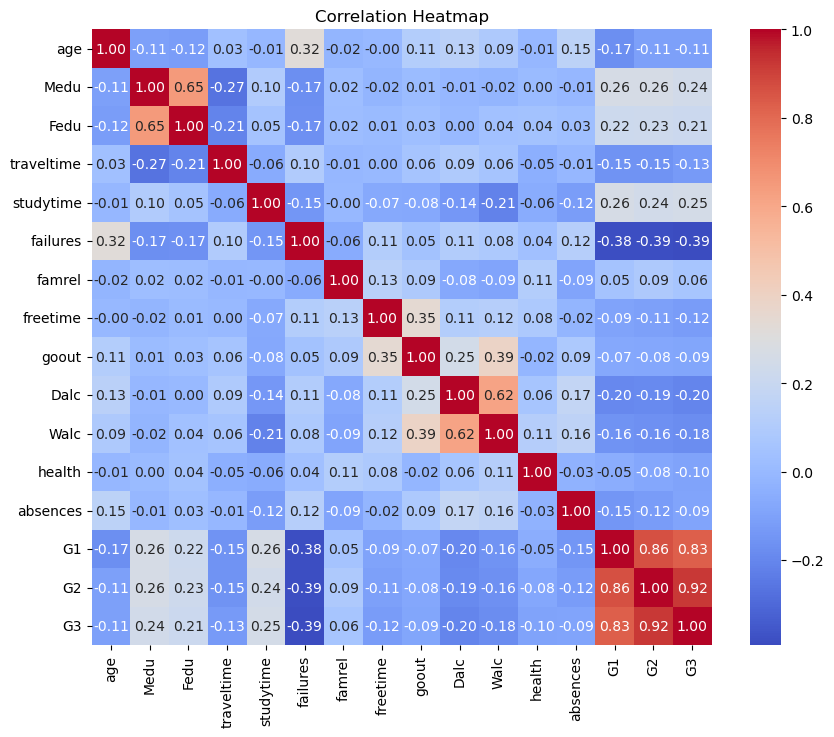

In [11]:
# Display the correlation between numerical features

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The heatmap shows that **G2 (0.92)** and **G1 (0.83)** have the strongest positive correlations with the final grade (**G3**), while **previous failures (-0.39)** have the strongest negative correlation. Features such as **study time** and **mother's education** show moderate positive relationships. These insights help identify important features for later feature selection and model development.

### 2.3.2.2 Relationship Between Key Numerical Features and G3

### G2 vs G3

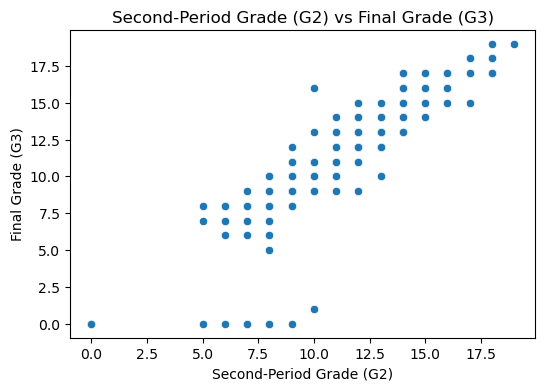

In [12]:
# Compare second-period grade with final grade
plt.figure(figsize=(6,4))

sns.scatterplot(data=df, x="G2", y="G3")

plt.title("Second-Period Grade (G2) vs Final Grade (G3)")
plt.xlabel("Second-Period Grade (G2)")
plt.ylabel("Final Grade (G3)")

plt.show()


Students with higher **G2** scores generally achieved higher final grades (**G3**), indicating a strong positive relationship. This suggests that G2 is an important predictor of final academic performance.

### Study Time vs G3

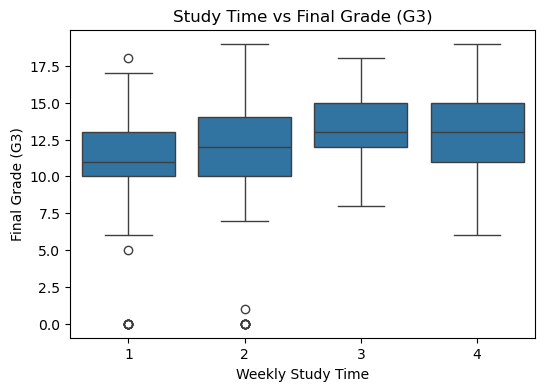

In [13]:
# Compare study time with final grade
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="studytime", y="G3")

plt.title("Study Time vs Final Grade (G3)")
plt.xlabel("Weekly Study Time")
plt.ylabel("Final Grade (G3)")

plt.show()


Students who studied for longer periods generally achieved slightly higher final grades. However, the overlap between groups suggests that study time alone does not determine academic performance.

### Previous Failures vs G3

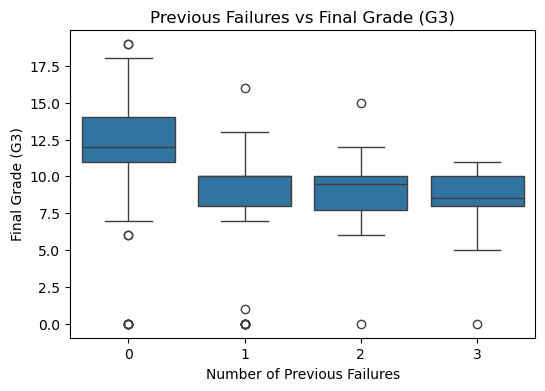

In [14]:
# Compare previous failures with final grade
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="failures", y="G3")

plt.title("Previous Failures vs Final Grade (G3)")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade (G3)")

plt.show()


Students with no previous failures generally achieved higher final grades than those with one or more failures. This indicates that previous academic performance is an important predictor of future results.

### Mother's Education vs G3

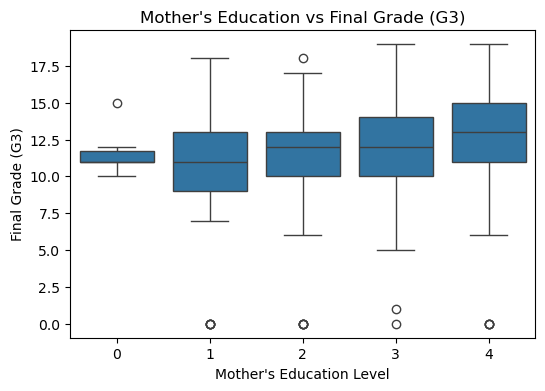

In [15]:
# Compare mother's education with final grade
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Medu", y="G3")

plt.title("Mother's Education vs Final Grade (G3)")
plt.xlabel("Mother's Education Level")
plt.ylabel("Final Grade (G3)")

plt.show()


Students whose mothers had higher education levels tend to slightly achieve slightly higher final grades. This suggests that family educational background may positively influence academic performance.

### 2.3.2.3 Relationship Between Categorical Features and Final Grade (G3)

Several categorical features are explored to determine whether different student groups exhibit differences in academic performance.

### Higher Education vs G3

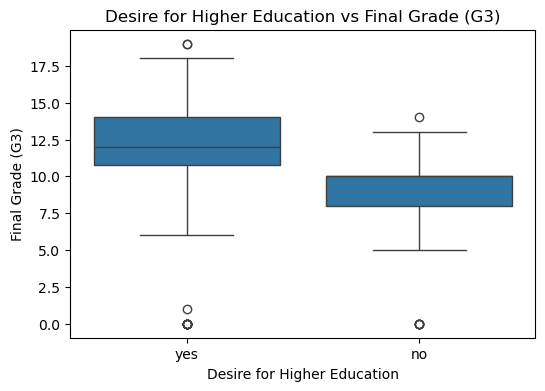

In [16]:
# Compare students' desire for higher education with final grade
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="higher", y="G3")

plt.title("Desire for Higher Education vs Final Grade (G3)")
plt.xlabel("Desire for Higher Education")
plt.ylabel("Final Grade (G3)")

plt.show()


Students who intend to pursue higher education generally achieved higher final grades, suggesting that educational aspirations may be associated with stronger academic performance.

### Internet vs G3

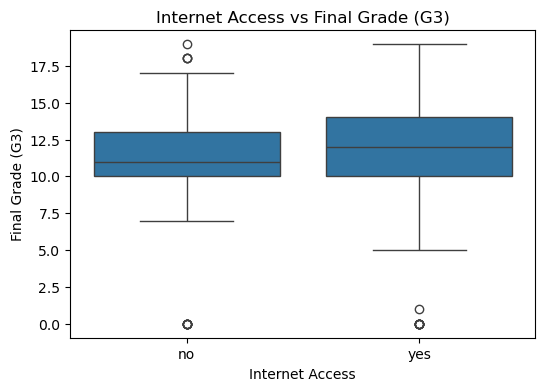

In [17]:
# Compare internet access with final grade
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="internet", y="G3")

plt.title("Internet Access vs Final Grade (G3)")
plt.xlabel("Internet Access")
plt.ylabel("Final Grade (G3)")

plt.show()


Students with internet access generally achieved slightly higher final grades. However, the difference between the two groups is relatively small.

### School vs G3 

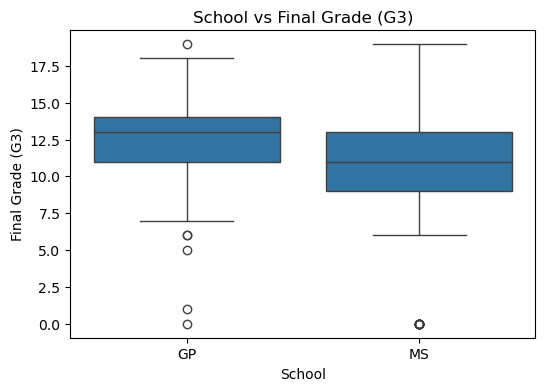

In [18]:
# Compare school with final grade
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="school", y="G3")

plt.title("School vs Final Grade (G3)")
plt.xlabel("School")
plt.ylabel("Final Grade (G3)")

plt.show()


The distribution of final grades is broadly similar across both schools, suggesting that school attended is not a major factor influencing students' academic performance.

# 3. Data Preparation

## 3.1 Data Cleaning


Data cleaning ensures that the dataset is suitable for machine learning by checking for duplicate records and handling any data quality issues. Since missing values were previously examined during data understanding, this section focuses on identifying duplicate entries before model training.

In [19]:
# Check for duplicate rows and missing values in the dataset

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:")
print(df.isnull().sum())

Duplicate rows: 0
Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64



No duplicate rows or missing values were found in the dataset. Therefore, no additional cleaning or imputation was required before model development.

### Convert Grades into categories

In [20]:
# Convert numerical final grade (G3) into grade categories

def convert_grade(score):
    if score >= 16:
        return "A"
    elif score >= 11:
        return "B"
    elif score >= 6:
        return "C"
    else:
        return "D"

df["Grade"] = df["G3"].apply(convert_grade)

display(df[["G3", "Grade"]].head())

display(df["Grade"].value_counts().sort_index())

,G3,Grade
0,11,B
1,11,B
2,12,B
3,14,B
4,13,B


Grade
A     82
B    370
C    180
D     17
Name: count, dtype: int64


The numerical final grade (G3) was converted into four grade categories (A, B, C, and D) to transform the problem into a classification task. The resulting class distribution shows some imbalance, with Grade B containing the most students and Grade D the fewest.

In [21]:
df.drop(columns=["G3"], inplace=True)
df.drop(columns=["G1"], inplace=True)


The original target variable (G3) was removed to prevent target leakage. G1 was also removed because it represents an earlier academic assessment, while G2 captures more recent performance and has the strongest correlation with the final grade.

### One Hot Encoding

In [22]:
# Identify categorical features
categorical_features = df.select_dtypes(include="object").drop(columns=["Grade"]).columns

# Apply one-hot encoding
df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

# Convert target labels into numerical classes
grade_mapping = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3
}

df["Grade"] = df["Grade"].map(grade_mapping)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                649 non-null    int64
 1   Medu               649 non-null    int64
 2   Fedu               649 non-null    int64
 3   traveltime         649 non-null    int64
 4   studytime          649 non-null    int64
 5   failures           649 non-null    int64
 6   famrel             649 non-null    int64
 7   freetime           649 non-null    int64
 8   goout              649 non-null    int64
 9   Dalc               649 non-null    int64
 10  Walc               649 non-null    int64
 11  health             649 non-null    int64
 12  absences           649 non-null    int64
 13  G2                 649 non-null    int64
 14  Grade              649 non-null    int64
 15  school_MS          649 non-null    bool 
 16  sex_M              649 non-null    bool 
 17  address_U       

One-hot encoding converts categorical variables into numerical format required by machine learning models while avoiding redundant dummy variables using drop_first=True.

In [23]:
# Display the dataset after preprocessing
df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


### Feature Selection Decision

No additional features were removed during the initial data cleaning stage because the Student Performance dataset does not contain any obviously redundant or irrelevant columns (e.g., ID numbers or index columns). Each feature represents a meaningful characteristic of a student's demographic, family background, lifestyle, or academic performance that may contribute to predicting the final grade.

Based on the exploratory data analysis and the project requirements, only the original target variable (**G3**) and **G1** were removed during preprocessing. G3 was removed to prevent target leakage after creating the new target variable (**Grade**), while G1 was removed because G2 provides more recent academic performance information and showed a stronger correlation with the final grade.

Additional feature engineering and feature selection experiments were performed later during the iterative model development stage after selecting the best-performing model.

### Feature Engineering (Domain Knowledge) #

 weekday (Dalc) and weekend (Walc) alcohol consumption were combined into a single feature representing a student's overall alcohol consumption. This was expected to provide a more comprehensive measure of drinking behaviour while reducing redundancy between two closely related variables.

In [24]:
# # # Combine weekday and weekend alcohol consumption
df["Total_Alcohol"] = df["Dalc"] + df["Walc"]

# # # Remove original columns
df = df.drop(columns=["Dalc", "Walc"])

### Feature Engineering Experiment

After selecting the best-performing baseline model, an additional feature engineering experiment was conducted by combining the mother's and father's education levels into a single feature representing the family's overall educational background. The objective was to determine whether this combined feature could improve model performance.

In [25]:
# Feature Engineering Experiment (Rejected)

# df["Parent_Education"] = df["Medu"] + df["Fedu"]

# df = df.drop(columns=["Medu", "Fedu"])


Combining the mother's and father's education into a single feature did not improve model performance. Keeping both variables separately preserved more information about each parent's educational background. Therefore, this feature engineering experiment was rejected, and the original features were retained.

## 3.2 Train-Test Split

The prepared dataset is divided into training and testing sets before model training. The training set is used to train the machine learning models, while the testing set is reserved for evaluating model performance on unseen data.

An **80:20 split** is used, with a fixed **random state** to ensure reproducibility. **Stratified sampling** is also applied to preserve the distribution of grade categories in both the training and testing datasets.

In [26]:
# Separate the features (X) and target variable (y)
X = df.drop(columns=["Grade"])
y = df["Grade"]

In [27]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
# Display the size of each dataset
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (519, 39)
X_test: (130, 39)
y_train: (519,)
y_test: (130,)



The dataset was successfully split into training and testing sets using an 80:20 ratio. Stratified sampling preserved the distribution of grade categories in both datasets, while the fixed random state ensures that the results can be reproduced consistently.

In [29]:
# Display the class distribution in the training and testing sets
print("Training Set Grade Distribution")
display(y_train.value_counts().sort_index())

print("Testing Set Grade Distribution")
display(y_test.value_counts().sort_index())

Training Set Grade Distribution


Grade
0     65
1    296
2    144
3     14
Name: count, dtype: int64

Testing Set Grade Distribution


Grade
0    17
1    74
2    36
3     3
Name: count, dtype: int64


The class distribution in the training and testing sets remains similar to the original dataset, confirming that stratified sampling successfully preserved the proportion of each grade category.

# 4. Modelling

Four classification algorithms were trained and evaluated using the same training and testing datasets. Their performance was compared using Accuracy, Precision, Recall, and F1-score to identify the most suitable model for deployment.

## 4.1 Logistic Regression

Logistic Regression is used as the baseline model because it is a simple and effective algorithm for multiclass classification problems. It provides a benchmark for comparing the performance of other machine learning models.

In [30]:
# # Initialise the Logistic Regression model
logistic_model = LogisticRegression(
     max_iter=1000,
     random_state=42
 )


In [31]:
print(X_train.shape)
print(X_train.columns.tolist())

(519, 39)
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G2', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes', 'Total_Alcohol']


In [32]:
# # Train the Logistic Regression model
logistic_model.fit(X_train, y_train)

c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [33]:
# Predict the grade categories for the testing dataset
y_pred_lr = logistic_model.predict(X_test)

In [34]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_lr, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_lr, average="weighted"))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.8538461538461538
Precision: 0.861062271062271
Recall   : 0.8538461538461538
F1-score : 0.8555100282305619
              precision    recall  f1-score   support

           0       0.76      0.94      0.84        17
           1       0.91      0.86      0.89        74
           2       0.83      0.81      0.82        36
           3       0.50      0.67      0.57         3

    accuracy                           0.85       130
   macro avg       0.75      0.82      0.78       130
weighted avg       0.86      0.85      0.86       130

[[16  1  0  0]
 [ 5 64  5  0]
 [ 0  5 29  2]
 [ 0  0  1  2]]


### Interpretation

Logistic Regression achieved an **accuracy of 85.38%**, making it a strong baseline model. It also obtained the highest weighted precision, recall, and F1-score among all evaluated models.

The model classified Grades **A**, **B**, and **C** effectively, while performance for Grade **D** was lower due to the limited number of samples in that class. Overall, Logistic Regression provides strong and consistent performance for predicting student grade categories.

# 4.2 Decision Tree

Decision Tree is trained to compare its performance against Logistic Regression. Unlike Logistic Regression, Decision Tree can capture non-linear relationships and is easy to interpret through its tree-based structure.

In [35]:
# Initialise the Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [36]:

# Predict the testing dataset
y_pred_dt = dt_model.predict(X_test)

In [37]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_dt, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_dt, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_dt))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.7692307692307693
Precision: 0.7725083612040134
Recall   : 0.7692307692307693
F1-score : 0.7668531468531469
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        17
           1       0.81      0.81      0.81        74
           2       0.77      0.64      0.70        36
           3       0.33      0.33      0.33         3

    accuracy                           0.77       130
   macro avg       0.65      0.68      0.66       130
weighted avg       0.77      0.77      0.77       130

[[16  1  0  0]
 [ 7 60  7  0]
 [ 0 11 23  2]
 [ 0  2  0  1]]


### Interpretation

The Decision Tree achieved an accuracy of **76.92%**, which is considerably lower than the Logistic Regression baseline. Although the model captured some patterns in the data, it produced more misclassifications, particularly for Grades C and D.

The lower performance suggests that the default Decision Tree may have overfitted the training data, resulting in weaker generalisation on unseen data.

# 4.3 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is trained to compare its performance against Logistic Regression and Decision Tree.

In [38]:
# Initialise the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict the testing dataset
y_pred_rf = rf_model.predict(X_test)




In [39]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_rf, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_rf))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.8307692307692308
Precision: 0.8109890109890109
Recall   : 0.8307692307692308
F1-score : 0.8206826286296486
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.86      0.89      0.87        74
           2       0.78      0.78      0.78        36
           3       0.00      0.00      0.00         3

    accuracy                           0.83       130
   macro avg       0.61      0.62      0.62       130
weighted avg       0.81      0.83      0.82       130

[[14  3  0  0]
 [ 3 66  5  0]
 [ 0  8 28  0]
 [ 0  0  3  0]]


c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afsh

### Interpretation

Random Forest achieved an accuracy of **83.07%**, outperforming the Decision Tree but remaining below Logistic Regression.

The ensemble approach reduced overfitting and improved overall prediction performance. However, its evaluation metrics were still slightly lower than the Logistic Regression model, indicating that it was not the best-performing model for this dataset.

# 4.4 Gradient Boosting

Gradient Boosting is an ensemble learning algorithm that builds decision trees sequentially, where each new tree attempts to correct the errors made by the previous trees. It is evaluated to compare its performance with the other classification models.

In [40]:
# Initialise the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict the testing dataset
y_pred_gb = gb_model.predict(X_test)

In [41]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_gb, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_gb, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_gb))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_gb))

Accuracy : 0.8538461538461538
Precision: 0.8578521478521478
Recall   : 0.8538461538461538
F1-score : 0.8532807363576594
              precision    recall  f1-score   support

           0       0.73      0.94      0.82        17
           1       0.91      0.86      0.89        74
           2       0.83      0.83      0.83        36
           3       0.50      0.33      0.40         3

    accuracy                           0.85       130
   macro avg       0.74      0.74      0.74       130
weighted avg       0.86      0.85      0.85       130

[[16  1  0  0]
 [ 6 64  4  0]
 [ 0  5 30  1]
 [ 0  0  2  1]]


### Interpretation

Gradient Boosting achieved an accuracy of 85.38%, making it one of the best-performing models alongside Logistic Regression.

The model achieved competitive precision, recall, and F1-score, showing that it can effectively classify student grade categories. However, Logistic Regression achieved slightly higher precision and F1-score while being simpler and easier to interpret. Therefore, Gradient Boosting was not selected as the final model despite its strong performance.

### Model Comparison

In [42]:
# Create a summary table comparing all models

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average="weighted"),
        precision_score(y_test, y_pred_dt, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_gb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average="weighted"),
        recall_score(y_test, y_pred_dt, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_gb, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_gb, average="weighted")
    ]
})

comparison

c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.853846,0.861062,0.853846,0.855510
1,Decision Tree,0.769231,0.772508,0.769231,0.766853
2,Random Forest,0.830769,0.810989,0.830769,0.820683
3,Gradient Boosting,0.853846,0.857852,0.853846,0.853281


### Model Comparison Table Interpretation

The comparison shows that Logistic Regression and Gradient Boosting achieved the highest accuracy of 85.38% among the four models.

Logistic Regression achieved slightly higher precision (86.11%) and F1-score (85.55%) compared to Gradient Boosting, indicating slightly better overall classification performance. Decision Tree achieved the lowest performance, while Random Forest improved upon Decision Tree but did not outperform the top-performing models.

Overall, Logistic Regression and Gradient Boosting demonstrated the most suitable performance for predicting student grade categories.

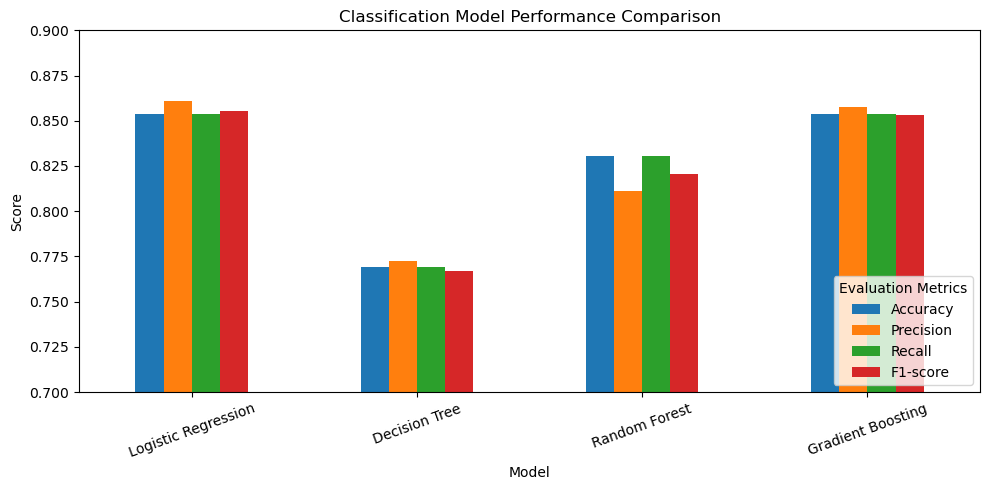

In [43]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0.7,0.9)

plt.xticks(rotation=20)

plt.legend(
    title="Evaluation Metrics",
    loc="lower right"
)

plt.tight_layout()

plt.show()

### Interpretation

The graph compares the performance of four classification models using accuracy, precision, recall, and F1-score. Logistic Regression and Gradient Boosting achieved the strongest overall performance, with both models obtaining an accuracy of 85.38%. Logistic Regression achieved slightly higher precision and F1-score, indicating a slightly better balance between correctly identifying grade categories and reducing classification errors. Decision Tree showed the lowest performance, while Random Forest provided improvement but did not outperform the top-performing models. Therefore, Logistic Regression was selected due to its competitive predictive performance, interpretability, and suitability for deployment.

## 4.6 Model Selection

Based on the evaluation results, Logistic Regression was selected as the final model.

Although Logistic Regression and Gradient Boosting achieved the same accuracy (85.38%), Logistic Regression achieved slightly higher precision (86.11%) and F1-score (85.55%). Additionally, Logistic Regression provides better interpretability compared to ensemble models such as Random Forest and Gradient Boosting, allowing the relationship between features and predictions to be analysed more easily.

In this application, prediction errors should also be considered from a practical perspective. Misclassifying a student who is actually performing poorly as a higher grade may be more costly, as the student may not receive the necessary academic support. Therefore, maintaining good overall classification performance and reducing incorrect predictions is important.

Since the application focuses on predicting student grade categories, interpretability and deployment efficiency are important considerations. Therefore, Logistic Regression was selected as the final model for further feature engineering, hyperparameter tuning, and final evaluation.


## 5. Evaluation Metric Selection

Accuracy was selected as the primary evaluation metric because the objective of this project is to correctly classify students into their final grade categories. It provides an overall measure of how many predictions were correctly classified across all grade categories.

However, relying on accuracy alone may not provide a complete assessment of model performance. Therefore, Precision, Recall, and F1-score were also evaluated to measure how well each model classified individual grade categories and to ensure that the model performed consistently across the dataset.

The baseline Logistic Regression model achieved the strongest overall balance across Accuracy, Precision, Recall, and F1-score. These evaluation metrics indicate that the model is able to classify student grade categories reliably while minimising incorrect classifications,reducing the likelihood of students receiving inappropriate academic support due to incorrect predictions and making it suitable for supporting teachers and school counsellors in identifying students who may require additional academic support.

## Iterative model development


## 6. Feature Engineering & Feature Selection

After selecting Logistic Regression as the best-performing model, feature importance was analysed to understand which variables contributed most to the prediction. Based on these findings, feature engineering and feature selection experiments were conducted to evaluate whether model performance could be further improved.


### 6.1 Feature Importance Analysis

Feature importance analysis is performed on the selected Logistic Regression model to identify which features have the greatest influence on predicting student grade categories. The results are used to guide feature engineering and feature selection experiments.

In [44]:
# Get Logistic Regression coefficients

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": abs(logistic_model.coef_).mean(axis=0)
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
11,G2,1.632976
18,Mjob_other,0.628801
5,failures,0.453290
13,sex_M,0.422048
31,famsup_yes,0.395763
29,guardian_other,0.390282
21,Fjob_health,0.358976
30,schoolsup_yes,0.348376
12,school_MS,0.330843
17,Mjob_health,0.329702


### Interpretation

The feature importance analysis shows that **G2** is the most influential feature for predicting the final grade category. Features such as **failures**, **Dalc**, and **study-related or demographic variables** also contributed to the model, while several other features had relatively low importance.

These results provide a basis for identifying features to evaluate during the feature engineering and feature selection stage.

### Top 10 important features

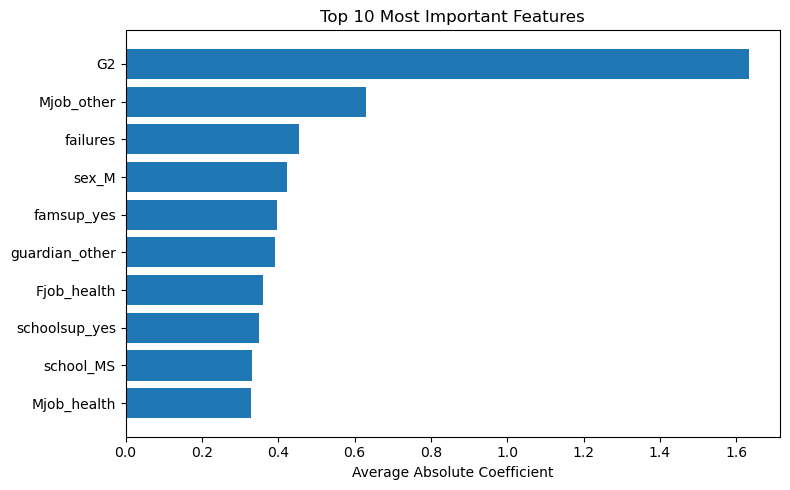

In [45]:
# Display the top 10 most important features

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")
plt.xlabel("Average Absolute Coefficient")

plt.tight_layout()

plt.show()

The results show that G2 is the strongest predictor of final grade, which is expected because it represents the student's second-period academic performance. Other influential features include previous failures and parental education, suggesting both academic history and family background contribute to prediction.

### Feature Engineering remove least important features

In [46]:
# Select least important features

least_features = feature_importance.tail(10)

features_to_remove = least_features["Feature"].tolist()

print(features_to_remove)

['famsize_LE3', 'famrel', 'Mjob_teacher', 'paid_yes', 'address_U', 'Mjob_services', 'internet_yes', 'Medu', 'activities_yes', 'Pstatus_T']


In [47]:
X_selected = X.drop(columns=features_to_remove)


In [48]:
# Split the selected features into training and testing datasets

X_train_selected, X_test_selected, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create a new Logistic Regression model using the selected features

logistic_selected = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the selected training dataset

logistic_selected.fit(
    X_train_selected,
    y_train
)

# Predict student grade categories using the testing dataset

y_pred_selected = logistic_selected.predict(
    X_test_selected
)

# Evaluate the model accuracy after feature selection

print(
    accuracy_score(
        y_test,
        y_pred_selected
    )
)

0.8538461538461538


c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
comparison_feature = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Logistic Regression After Feature Selection"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_selected)
    ]
})

comparison_feature

,Model,Accuracy
0,Baseline Logistic Regression,0.853846
1,Logistic Regression After Feature Selection,0.853846


### Feature Selection Evaluation

Feature selection was explored by removing the least important features identified from the Logistic Regression feature importance analysis. The purpose was to determine whether reducing the number of input features could improve model performance by removing less influential variables.

However, the selected features included several one-hot encoded categorical variables, such as different categories of parental occupation and student background factors. Removing individual encoded categories does not necessarily mean the entire original feature is unimportant, as other categories from the same variable may still contribute useful information.

Feature selection did not improve the model's predictive performance, as the evaluation metrics remained unchanged after removing the least important features. This suggests that although some features had relatively small individual contributions, retaining the complete feature set preserved useful information and avoided unnecessary loss of potentially relevant predictors.. Therefore, the original feature set was retained to preserve the information represented by the categorical variables while maintaining the same predictive performance.

## Hyperparameter Tuning

RandomizedSearchCV was applied to the Logistic Regression model to investigate whether adjusting model hyperparameters could improve performance compared to the baseline model.

Two hyperparameters were tuned:
- C: Controls the strength of regularisation
- Solver: Determines the optimisation algorithm used during training

A 5-fold cross-validation approach was used to evaluate different parameter combinations and identify the best-performing settings.

In [50]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Define the hyperparameter search space for RandomizedSearchCV
param_dist = {
    "C": [0.01, 0.1, 1],
    "solver": ["liblinear", "lbfgs", "newton-cg"]
}

In [ ]:
# Create the Logistic Regression model for hyperparameter tuning
logistic_model_tuning = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [53]:
# Perform hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=logistic_model_tuning,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring="accuracy",
    random_state=42
)

# Train using training data
random_search.fit(
    X_train,
    y_train
)


c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 

In [54]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'solver': 'newton-cg', 'C': 0.1}

Best Cross Validation Accuracy:
0.834353995519044


In [55]:
# Display tested parameter combinations and CV scores
tuning_results = pd.DataFrame(
    random_search.cv_results_
)

tuning_results[
    [
        "params",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
)

,params,mean_test_score,rank_test_score
2,"{'solver': 'newton-cg', 'C': 0.1}",0.834354,1
4,"{'solver': 'newton-cg', 'C': 1}",0.822741,2
0,"{'solver': 'lbfgs', 'C': 1}",0.820799,3
1,"{'solver': 'lbfgs', 'C': 0.01}",0.770855,4
3,"{'solver': 'liblinear', 'C': 0.01}",NaN,5


The table summarises the cross-validation performance of the different hyperparameter combinations evaluated using RandomizedSearchCV. The combination C = 0.1 and solver = "newton-cg" achieved the highest mean cross-validation accuracy of 0.8344, making it the best-performing configuration during hyperparameter tuning.


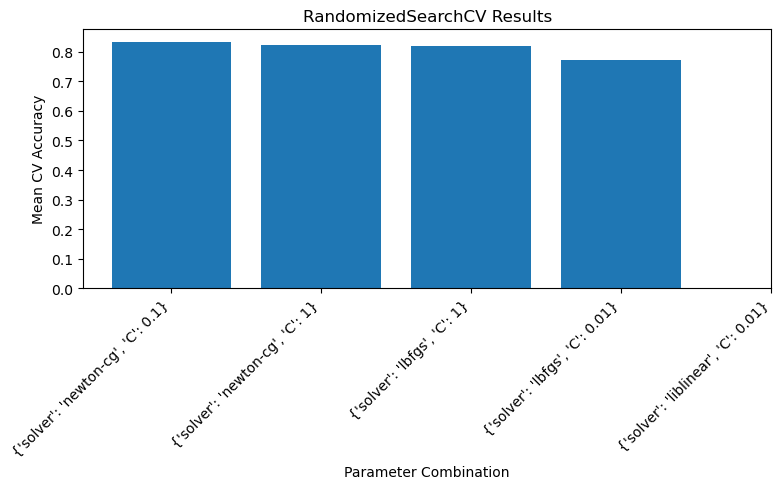

In [56]:
import matplotlib.pyplot as plt

cv_results = tuning_results.sort_values(
    by="mean_test_score",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    range(len(cv_results)),
    cv_results["mean_test_score"]
)

plt.xlabel("Parameter Combination")
plt.ylabel("Mean CV Accuracy")
plt.title("RandomizedSearchCV Results")

plt.xticks(
    range(len(cv_results)),
    cv_results["params"],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

The RandomizedSearchCV results show that different hyperparameter combinations produced similar cross-validation performance. The best combination was selected based on the highest mean CV accuracy.

In [ ]:
# Retrieve the best Logistic Regression model identified during hyperparameter tuning
best_logistic_model = random_search.best_estimator_
# Predict student grade categories using the tuned model
y_pred_tuned = best_logistic_model.predict(
    X_test
)

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)


print("Tuned Logistic Regression Performance")
print("------------------------------------")
print("Accuracy:", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall:", tuned_recall)
print("F1-score:", tuned_f1)

Tuned Logistic Regression Performance
------------------------------------
Accuracy: 0.8461538461538461
Precision: 0.8493927125506072
Recall: 0.8461538461538461
F1-score: 0.8435897435897436


In [59]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        tuned_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average="weighted"),
        tuned_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average="weighted"),
        tuned_recall
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        tuned_f1
    ]
})

tuning_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline Logistic Regression,0.853846,0.861062,0.853846,0.85551
1,Tuned Logistic Regression,0.846154,0.849393,0.846154,0.84359


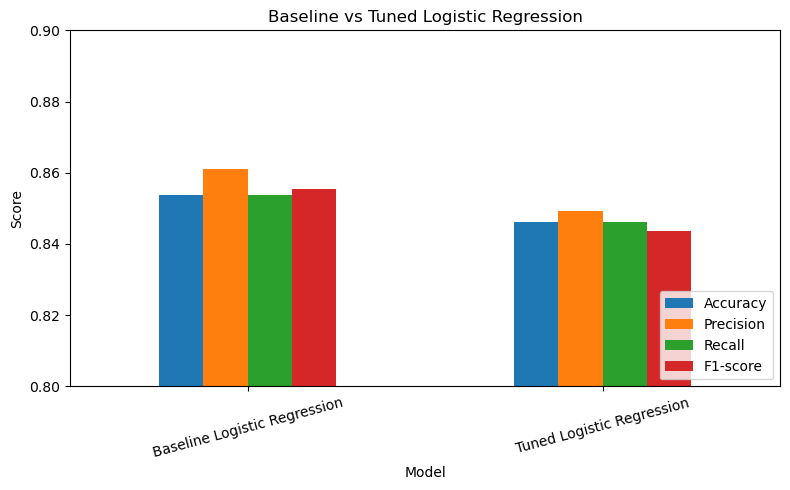

In [60]:
comparison_plot = tuning_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Tuned Logistic Regression")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=15)

plt.ylim(0.8,0.9)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()

The comparison shows that the baseline Logistic Regression model achieved better performance than the tuned model.

The baseline model achieved an accuracy of 85.38%, while the tuned model achieved 84.62%. Similar decreases were also observed in Precision, Recall, and F1-score.

This suggests that the baseline model was already well suited to the dataset, and adjusting the regularisation strength and optimisation algorithm did not improve its ability to generalise to unseen data.

Therefore, the baseline Logistic Regression model was retained as the final model due to its stronger predictive performance, better generalisation, and simpler implementation.

### Confusion Matrix for Final Model

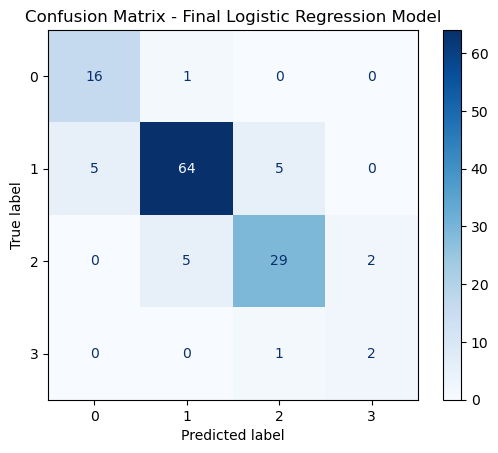

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Final Logistic Regression Model")
plt.show()

The confusion matrix shows that most predictions are located along the diagonal, indicating that the model correctly classified the majority of students. Most misclassifications occurred between neighbouring grade categories, suggesting that prediction errors were generally small rather than extreme.

## Final Model Selection


Based on the experimental results, the baseline Logistic Regression model was selected as the final model. It achieved the strongest overall balance across Accuracy, Precision, Recall, and F1-score while maintaining a simple and interpretable structure. Although Gradient Boosting achieved similar Accuracy and RandomizedSearchCV was performed to optimise Logistic Regression, neither approach produced better overall testing performance. Logistic Regression also provides greater transparency through interpretable feature coefficients and is computationally efficient, making it suitable for analysing factors affecting student performance and deploying within the application.

In [62]:
import joblib

# Save the final trained Logistic Regression model
joblib.dump(logistic_model, "student_grade_model.pkl")

print("Model saved successfully.")

# Save the feature names used during training
joblib.dump(X.columns.tolist(), "feature_names.pkl")

print("Feature names saved successfully.")

# Load the saved model to verify it was saved correctly
loaded_model = joblib.load("student_grade_model.pkl")

print("Model loaded successfully.")

# Load the saved feature names
loaded_features = joblib.load("feature_names.pkl")

print("Feature names loaded successfully.")

# Display the number of features
print(f"\nTotal Features: {len(loaded_features)}")

# Display all feature names
print("\nFeature Names:")
for feature in loaded_features:
    print(feature)

Model saved successfully.
Feature names saved successfully.
Model loaded successfully.
Feature names loaded successfully.

Total Features: 39

Feature Names:
age
Medu
Fedu
traveltime
studytime
failures
famrel
freetime
goout
health
absences
G2
school_MS
sex_M
address_U
famsize_LE3
Pstatus_T
Mjob_health
Mjob_other
Mjob_services
Mjob_teacher
Fjob_health
Fjob_other
Fjob_services
Fjob_teacher
reason_home
reason_other
reason_reputation
guardian_mother
guardian_other
schoolsup_yes
famsup_yes
paid_yes
activities_yes
nursery_yes
higher_yes
internet_yes
romantic_yes
Total_Alcohol
